<a href="https://colab.research.google.com/github/himabindusgs-svg/LinearRegression/blob/main/STUDENT_ENGAGEMENT_SEGMENTATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:

   LMS_Hours  Library_Visits  Attendance
0          1               1          40
1          2               2          45
2          3               3          50
3          5               5          70
4          6               6          75
5          7               7          80
6          9               9          90
7         10              10          95
   LMS_Hours  Library_Visits  Attendance
0          1               1          40
1          2               2          45
2          3               3          50
3          5               5          70
4          6               6          75
5          7               7          80
6          9               9          90
7         10              10          95

Predicted Clusters

[0 0 0 2 2 2 1 1]

Cluster Centers

[[ 2.   2.  45. ]
 [ 9.5  9.5 92.5]
 [ 6.   6.  75. ]]

Updated Dataset

   LMS_Hours  Library_Visits  Attendance  Predicted  Mapped_Predicted  \
0          1               1          40         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


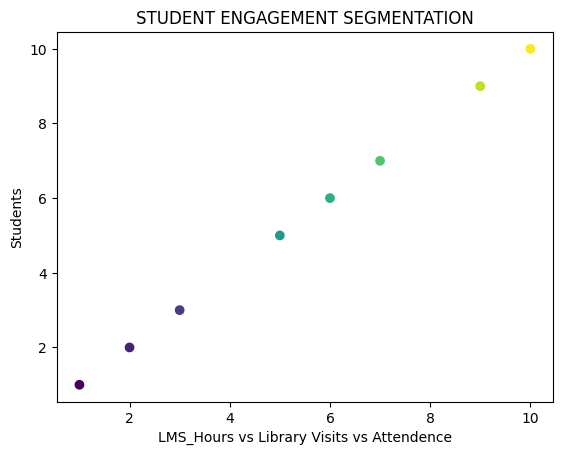

In [4]:
# STUDENT ENGAGEMENT SEGMENTATION

# (K-Means Clustering)
# The university wants to group students into:
# Low Engagement
# Medium Engagement
# High Engagement
# based on:
# LMS Usage Hours
# Library Visits
# Attendance
# Tasks
# Train a K-Means model with 3 clusters.
# Predict clusters for students.
# Assign cluster labels:
# Low Engagement
# Medium Engagement
# High Engagement
# Visualize clusters using Matplotlib.


import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)


# ============================================
# Create Dataset
# ============================================

# STEP 2 — Upload CSV file

uploaded = files.upload()


# STEP 3 — Load dataset

df = pd.read_csv("StudentEngagement.csv")


# STEP 4 — Display dataset

print("Dataset:\n")
print(df)


print(df)

# ============================================
# Select Input Features
# ============================================

X = df[['LMS_Hours','Library_Visits', 'Attendance']]


# ============================================
# Train K-Means
# ============================================

model = KMeans(
    n_clusters=3,
    random_state=42
)

model.fit(X)


# ============================================
# Predict Clusters
# ============================================

predicted = model.labels_
df['Predicted'] = predicted


print("\nPredicted Clusters\n")

print(predicted)


# ============================================
# IMPORTANT:
# K-Means labels are random
# ============================================

print("\nCluster Centers\n")

print(model.cluster_centers_)


# Actual learned clusters:

# Cluster 2 → Low
# Cluster 0 → Medium
# Cluster 1 → High


cluster_mapping = {

2:0,
0:1,
1:2

}


df['Mapped_Predicted'] = (
    df['Predicted']
    .map(cluster_mapping)
)
# Human-friendly labels

activity_map = {

0:'Low Activity',
1:'Medium Activity',
2:'High Activity'

}


df['Activity_Level']=(
    df['Mapped_Predicted']
    .map(activity_map)
)


print("\nUpdated Dataset\n")

print(df)


# ============================================
# Evaluation
# ============================================

accuracy = accuracy_score(

    df['Attendance'],

    df['Mapped_Predicted']

)


precision = precision_score(

    df['Attendance'],

    df['Mapped_Predicted'],

    average='macro'
    )


recall = recall_score(

    df['Attendance'],

    df['Mapped_Predicted'],

    average='macro'

)


print("\nAccuracy:",accuracy)

print("Precision:",precision)

print("Recall:",recall)


# ============================================
# Visualization
# ============================================

plt.scatter(

    df['LMS_Hours'],

    df['Library_Visits'],

    c=df['Attendance']

)

plt.xlabel("LMS_Hours vs Library Visits vs Attendence")

plt.ylabel("Students")

plt.title(
    "STUDENT ENGAGEMENT SEGMENTATION"
    )

plt.show()
